<a href="https://colab.research.google.com/github/MaysNassar/-Metabolic-Syndrome-Prediction/blob/main/Metabolic_Syndrome_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



---


# **Metabolic Syndrome Prediction**


----
- Mays Nassar


> Description:
To predict metabolic syndrome, yes or not based on common risk factors
Summary.

The dataset for analysis came from the NHANES initiative where the following variables were combined from multiple tables with SQL: abnormal waist circumference, triglycerides above 150, HDL cholesterol below 50 in women or 40 in men, history of hypertension and mildly elevated fasting blood sugar (100-125). Numerous other variables were added, such as uric acid, race, income, etc. that might contribute to the model but we will not sure, until we test the model.


## **Data Dictionary**
| Feature | Full Name | Data Type | Description | Unit | Clinical Relevance |
|---------|-----------|-----------|-------------|------|-------------------|
| seqn | Sequence Number | Integer | Unique participant identifier | N/A | Identifier only |
| Age | Age | Integer | Age of participant at examination | Years | Risk factor; increases with age |
| Sex | Biological Sex | Categorical | Male or Female | N/A | Clinical diagnostic criterion differs by sex |
| Marital | Marital Status | Categorical | Single, Married, Widowed, Divorced, Separated | N/A | Sociodemographic variable |
| Income | Annual Household Income | Numeric | Self-reported household income level | USD/year | Socioeconomic status |
| Race | Race/Ethnicity | Categorical | White, Black, Asian, Hispanic, Mexican American, Other | N/A | Risk varies by ethnicity; social determinant of health |
| WaistCirc | Waist Circumference | Numeric | Measurement around waist at umbilicus | Centimeters (cm) | **Core metabolic syndrome criterion**: >102cm (men), >88cm (women) |
| BMI | Body Mass Index | Numeric | Weight in kg / (height in m)² | kg/m² | Indicator of obesity; correlates with metabolic risk |
| Albuminuria | Albumin in Urine (Severity) | Ordinal | 0 = None, 1 = Microalbuminuria, 2 = Macroalbuminuria | Categorical | Indicator of kidney dysfunction severity; metabolic marker |
| UrAlbCr | Urine Albumin-to-Creatinine Ratio | Numeric | Amount of albumin relative to creatinine in urine | mg/g creatinine | Early marker of kidney damage; elevated in metabolic disease |
| UricAcid | Serum Uric Acid | Numeric | Concentration of uric acid in blood | mg/dL | Associated with metabolic syndrome and gout |
| BloodGlucose | Fasting Blood Glucose | Numeric | Blood glucose after fasting | mg/dL | **Core metabolic syndrome criterion**: 100-125 mg/dL |
| HDL | HDL Cholesterol | Numeric | High-density lipoprotein cholesterol | mg/dL | **Core metabolic syndrome criterion**: <50 mg/dL (women), <40 mg/dL (men) |
| Triglycerides | Serum Triglycerides | Numeric | Concentration of triglycerides in blood | mg/dL | **Core metabolic syndrome criterion**: >150 mg/dL |
| MetabolicSyndrome | Metabolic Syndrome Diagnosis | Categorical | "MetSyn" (Yes) or "No MetSyn" (No) | Binary | **Target Variable** |


# Load Data

In [84]:
## Our standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [86]:

df = pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/Metabolic  Syndrome.csv')

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2401 entries, 0 to 2400
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   seqn               2401 non-null   int64  
 1   Age                2401 non-null   int64  
 2   Sex                2401 non-null   object 
 3   Marital            2193 non-null   object 
 4   Income             2284 non-null   float64
 5   Race               2401 non-null   object 
 6   WaistCirc          2316 non-null   float64
 7   BMI                2375 non-null   float64
 8   Albuminuria        2401 non-null   int64  
 9   UrAlbCr            2401 non-null   float64
 10  UricAcid           2401 non-null   float64
 11  BloodGlucose       2401 non-null   int64  
 12  HDL                2401 non-null   int64  
 13  Triglycerides      2401 non-null   int64  
 14  MetabolicSyndrome  2401 non-null   object 
dtypes: float64(5), int64(6), object(4)
memory usage: 281.5+ KB


,seqn,Age,Sex,Marital,Income,Race,WaistCirc,BMI,Albuminuria,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides,MetabolicSyndrome
0,62161,22,Male,Single,8200.0,White,81.0,23.3,0,3.88,4.9,92,41,84,No MetSyn
1,62164,44,Female,Married,4500.0,White,80.1,23.2,0,8.55,4.5,82,28,56,No MetSyn
2,62169,21,Male,Single,800.0,Asian,69.6,20.1,0,5.07,5.4,107,43,78,No MetSyn
3,62172,43,Female,Single,2000.0,Black,120.4,33.3,0,5.22,5.0,104,73,141,No MetSyn
4,62177,51,Male,Married,NaN,Asian,81.1,20.1,0,8.13,5.0,95,43,126,No MetSyn


In [87]:
# Check class impalance
df['MetabolicSyndrome'].value_counts(normalize=True)

,proportion
MetabolicSyndrome,
No MetSyn,0.657643
MetSyn,0.342357


- **Dataset Structure:**
    - 2,401 rows × 15 columns
    - Patient health records with metabolic syndrome classification

- **Target Variable**:
    - MetabolicSyndrome (binary classification: "MetSyn" / "No MetSyn")

- **Features**:
   - seqn (ID)
   - Age, Sex, Marital, Income, Race (demographics)
   - WaistCirc, BMI, Albuminuria, UrAlbCr, UricAcid, BloodGlucose, HDL,      Triglycerides (clinical)

- Each Row represents a single individual's health profile with demographic and clinical measurements

> **opportunities exist for dimensionality reduction or feature selection:**
 >  - WaistCirc and BMI are correlated (both measure body composition).
 >  - BloodGlucose, Triglycerides, HDL overlap in metabolic dysfunction signals.
 >  - Income has sparse data (4.9% missing)—may have weak predictive power.
    

> **challenges i foresee**:
>   - Missing values: Marital (8.7%), Income (4.9%), WaistCirc (3.5%), BMI (1.1%).
>   -  Class imbalance: 65.8% negative vs 34.2% positive—need F1/AUC instead of accuracy.
>   -  Outliers: Triglycerides (max 1562 vs median 103), UrAlbCr (max 821 vs median ~6).
>   -  Categorical encoding needed for Sex, Marital, Race.
>   -  Feature scaling required—wide value ranges (Age: 20-80, Triglycerides: 26-1562).

In [88]:
def summarize_df(df_):
  df = df_.copy()

  # Separate numeric and non-numeric columns
  numeric_cols = df.select_dtypes(include=['number']).columns

  report = pd.DataFrame({
    'Column': df.columns,
    'dtype': df.dtypes.values,
    '# null': df.isna().sum().values,
    'null (%)': (df.isna().sum().values / len(df) * 100).round(2),
    'nunique': df.nunique().values,
    'min': [df[col].min() if col in numeric_cols else 'N/A' for col in df.columns],
    'max': [df[col].max() if col in numeric_cols else 'N/A' for col in df.columns]
  })
  return report

summarize_df(df)

,Column,dtype,# null,null (%),nunique,min,max
0,seqn,int64,0,0.00,2401,62161,71915
1,Age,int64,0,0.00,61,20,80
2,Sex,object,0,0.00,2,N/A,N/A
3,Marital,object,208,8.66,5,N/A,N/A
4,Income,float64,117,4.87,14,300.0,9000.0
5,Race,object,0,0.00,6,N/A,N/A
6,WaistCirc,float64,85,3.54,635,56.2,176.0
7,BMI,float64,26,1.08,322,13.4,68.7
8,Albuminuria,int64,0,0.00,3,0,2
9,UrAlbCr,float64,0,0.00,1383,1.4,5928.0


- we have missing values in
  - Marital: 208 missing (8.66%) — categorical
  - Income: 117 missing (4.87%) — numeric
  - WaistCirc: 85 missing (3.54%) — numeric
  - BMI: 26 missing (1.08%) — numeric

we are gonna hva more ivestigation for imputing missing values

##  Duplicated

In [89]:
df_clean = df.copy()

In [90]:
# Check for dublicates
df_clean.duplicated().sum()

np.int64(0)

## Missing Values

## Basic EDA's

### Functions

In [91]:
# UNIVARIATE PLOTTING FUNCTIONS FOR EDA
def explore_categorical(df, x, fillna = True, placeholder = 'MISSING',
                        figsize = (6,4), order = None):
  """Creates a seaborn countplot with the option to temporarily fill missing values
  Prints statements about null values, cardinality, and checks for
  constant/quasi-constant features.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # Before filling nulls, save null value counts and percent for printing
  null_count = temp_df[x].isna().sum()
  null_perc = null_count/len(temp_df)* 100
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # Create figure with desired figsize
  fig, ax = plt.subplots(figsize=figsize)
  # Plotting a count plot
  sns.countplot(data=temp_df, x=x, ax=ax, order=order)
  # Rotate Tick Labels for long names
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title with the feature name included
  ax.set_title(f"Column: {x}", fontweight='bold')

  # Fix layout and show plot (before print statements)
  fig.tight_layout()
  plt.show()

  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = temp_df[x].nunique()
  print(f"- Unique Values: {nunique}")

  # First find value counts of feature
  val_counts = temp_df[x].value_counts(dropna=False)
  # Define the most common value
  most_common_val = val_counts.index[0]
  # Define the frequency of the most common value
  freq = val_counts.values[0]
  # Calculate the percentage of the most common value
  perc_most_common = freq / len(temp_df) * 100

  # Print the results
  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, ax


def explore_numeric(df, x, figsize=(6,5) ):
  """Creates a seaborn histplot and boxplot with a share x-axis,
  Prints statements about null values, cardinality, and checks for
  constant/quasi-constant features.
  Source:{PASTE IN FINAL LESSON LINK}
  """

  ## Save null value counts and percent for printing
  null_count = df[x].isna().sum()
  null_perc = null_count/len(df)* 100


  ## Making our figure with gridspec for subplots
  gridspec = {'height_ratios':[0.7,0.3]}
  fig, axes = plt.subplots(nrows=2, figsize=figsize,
                           sharex=True, gridspec_kw=gridspec)
  # Histogram on Top
  sns.histplot(data=df, x=x, ax=axes[0])

  # Boxplot on Bottom
  sns.boxplot(data=df, x=x, ax=axes[1])

  ## Adding a title
  axes[0].set_title(f"Column: {x}", fontweight='bold')

  ## Adjusting subplots to best fill Figure
  fig.tight_layout()

  # Ensure plot is shown before message
  plt.show()


  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = df[x].nunique()
  print(f"- Unique Values: {nunique}")


  # Get the most most common value, its count as # and as %
  most_common_val_count = df[x].value_counts(dropna=False).head(1)
  most_common_val = most_common_val_count.index[0]
  freq = most_common_val_count.values[0]
  perc_most_common = freq / len(df) * 100

  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")

  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, axes


In [92]:
# Updating function
def plot_categorical_vs_target(df, x, y,figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',
                            order = None, target_type='reg'):
  """Plots a combination of a seaborn barplot of means combined with
  a seaborn stripplot to show the spread of the data.
  Source:{PASTE IN FINAL LESSON LINK}
  """
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)

  # or drop nulls prevent unwanted 'nan' group in stripplot
  else:
    temp_df = temp_df.dropna(subset=[x])
  # Create the figure and subplots
  fig, ax = plt.subplots(figsize=figsize)

  ## REGRESSION-TARGET PLOT
  if target_type=='reg': # Add if statment here

   # Barplot
   sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
              linewidth=1, edgecolor='black', errorbar=None)

   # Boxplot
   sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                order=order, hue_order=order, legend=False,
                edgecolor='white', linewidth=0.5,
                size=3,zorder=0)

  # CLASSIFICATION_TARGET PLOT # this is the new code for the classification task
  elif target_type=='class':
    ax = sns.histplot(data=df, hue=y, x=x, stat='percent',
                  multiple='fill')
    # Rotate xlabels
  ax.set_xticks(ax.get_xticks()) # Add this to prevent a bug
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

  # Add a title
  ax.set_title(f"{x} vs. {y}", fontweight='bold')
  fig.tight_layout()
  return fig, ax

In [93]:
def plot_numeric_vs_target(df, x, y, figsize=(6,4),
                           target_type='reg', estimator='mean',
                           errorbar='ci', sorted=False, ascending=False,
                           **kwargs): # kwargs for sns.regplot

  nulls = df[[x,y]].isna().sum()
  if nulls.sum()>0:
    print(f"- Excluding {nulls.sum()} NaN's")
    temp_df = df.dropna(subset=[x,y])
  else:
    temp_df = df
  # Create the figure
  fig, ax = plt.subplots(figsize=figsize)

  # REGRESSION-TARGET PLOT
  if 'reg' in target_type:
   # Calculate the correlation
   corr = df[[x,y]].corr().round(2)
   r = corr.loc[x,y]
   # Plot the data
   scatter_kws={'ec':'white','linewidths':1,'alpha':0.8}
   sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws=scatter_kws,
               **kwargs)
   ## Add the title with the correlation
   ax.set_title(f"{x} vs. {y} (r = {r})", fontweight='bold')

  # CLASSIFICATION-TARGET PLOT
  elif 'class' in target_type:
    # Sort the groupes by median/mean
    if sorted == True:
      if estimator == 'median':
        group_vals = temp_df.groupby(y)[x].median()
      elif estimator == 'mean':
        group_vals = temp_df.groupby(y)[x].mean()

        ## Sort values
      group_vals = group_vals.sort_values(ascending=ascending)
      order = group_vals.index

    else:
      order = None



   # Left subplot(barplot)
    sns.barplot(data=temp_df, x=y, y=x, order=order, estimator=estimator,
                errorbar=errorbar, ax=ax, **kwargs)
   # Add title
    ax.set_title(f"{x} vs. {y}", fontweight='bold')

   # Rotate xaxis labels
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

  # Make sure the plot is shown before the print statement
  fig.tight_layout()
  plt.show()

  return fig, ax

## Heat Map

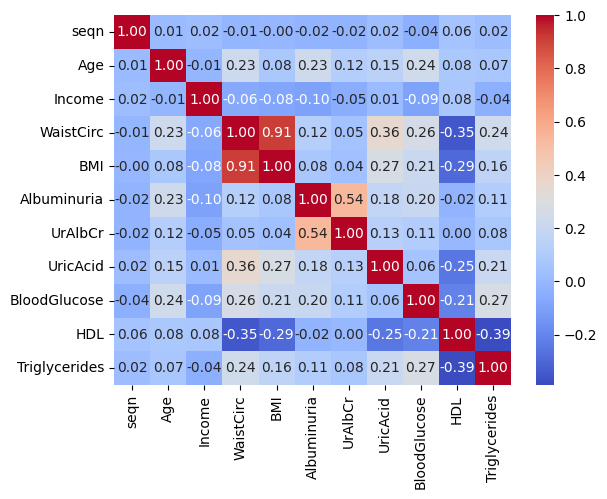

In [94]:
# Get corr
corr = df.corr(numeric_only= True)
# Make a heatmap of correlations
sns.heatmap(corr, cmap= 'coolwarm', annot= True, fmt='.2f');

### relation between Income and Target

- Excluding 117 NaN's


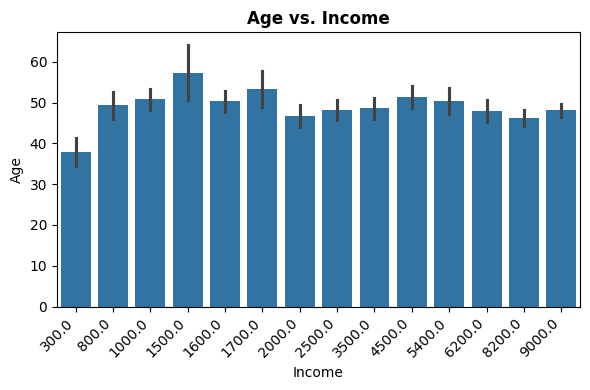

In [95]:
# See the relation between incom and target (MetabolicSyndrome)
plot_numeric_vs_target(df_clean, y='Income', x='Age',  target_type='class');


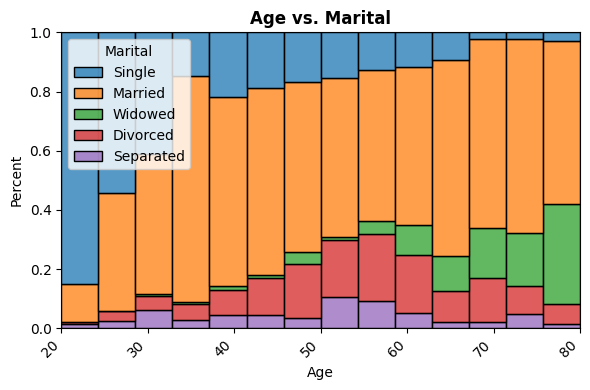

In [96]:
# See the realtion between Marital and age
plot_categorical_vs_target(df_clean, y='Marital', x='Age', target_type='class');

In [97]:
# Impute missing in marital with map with age
df_clean['Marital'].fillna(df_clean['Marital'].mode()[0], inplace=True)

/tmp/ipykernel_16132/1790905101.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Marital'].fillna(df_clean['Marital'].mode()[0], inplace=True)


In [98]:
#Create age groups (justified by looking at the data)
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=[0, 30, 45, 60, 100],
                         labels=['20-30', '30-45', '45-60', '60+'])

#  Impute Income
df_clean['Income'] = df_clean.groupby(['AgeGroup', 'Marital'])['Income'].transform(
    lambda x: x.fillna(x.median())
)
#  Handle any remaining nulls (groups with zero non-null Income values)
df_clean['Income'] = df_clean['Income'].fillna(df_clean['Income'].median())

/tmp/ipykernel_16132/197581370.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean['Income'] = df_clean.groupby(['AgeGroup', 'Marital'])['Income'].transform(


In [99]:
# Check missing values again
df_clean.isna().sum()

,0
seqn,0
Age,0
Sex,0
Marital,0
Income,0
Race,0
WaistCirc,85
BMI,26
Albuminuria,0
UrAlbCr,0


In [100]:
print(f"Rows before: {len(df)}")
print(f"Rows after: {len(df_clean)}")
print(f"Missing values remaining:")
print(df_clean.isnull().sum())

Rows before: 2401
Rows after: 2401
Missing values remaining:
seqn                  0
Age                   0
Sex                   0
Marital               0
Income                0
Race                  0
WaistCirc            85
BMI                  26
Albuminuria           0
UrAlbCr               0
UricAcid              0
BloodGlucose          0
HDL                   0
Triglycerides         0
MetabolicSyndrome     0
AgeGroup              0
dtype: int64


> Missing values in WaistCirc (85 cases, 3.54%) and BMI (26 cases, 1.08%) were imputed using mean values. WaistCirc was imputed separately by Sex using sex-specific means, as waist circumference measurements differ clinically between males and females due to biological differences in fat distribution. BMI was imputed using the overall mean, as BMI is a normalized metric already accounting for individual variation through the weight-to-height ratio. These features are core clinical predictors of metabolic syndrome and critical for model training. Mean imputation is appropriate given the small proportion of missing data (<4%) and maintains dataset size for robust model development. This approach is preferable to row deletion, which would remove valuable clinical information.


In [101]:
# Impute WaistCirc by Sex
df_clean['WaistCirc'] = df_clean.groupby('Sex')['WaistCirc'].transform(lambda x: x.fillna(x.mean()))

In [102]:
# Impute BMI overall mean
df_clean['BMI'].fillna(df_clean['BMI'].mean(), inplace=True)

/tmp/ipykernel_16132/1119066013.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['BMI'].fillna(df_clean['BMI'].mean(), inplace=True)


In [103]:
# Verify no missing values remain in these columns
print(df_clean[['WaistCirc', 'BMI']].isnull().sum())

WaistCirc    0
BMI          0
dtype: int64


## Inconsistent Values

In [104]:
# Check for inconsistent values
# Explore the value counts for all object cols
string_cols = df.select_dtypes(include='object').columns
for col in string_cols:
  print(f'Value Counts for {col}')
  print(df[col].value_counts())
  print('\n')

Value Counts for Sex
Sex
Female    1211
Male      1190
Name: count, dtype: int64


Value Counts for Marital
Marital
Married      1192
Single        498
Divorced      242
Widowed       166
Separated      95
Name: count, dtype: int64


Value Counts for Race
Race
White          933
Black          548
Asian          349
Hispanic       257
MexAmerican    253
Other           61
Name: count, dtype: int64


Value Counts for MetabolicSyndrome
MetabolicSyndrome
No MetSyn    1579
MetSyn        822
Name: count, dtype: int64




In [105]:
print("=" * 60)
print("IMPOSSIBLE VALUES CHECK")
print("=" * 60)
ranges = {
    'Age': (18, 100),
    'BMI': (10, 60),
    'WaistCirc': (50, 200),
    'BloodGlucose': (30, 400),
    'HDL': (10, 200),
    'Triglycerides': (10, 2000),
    'UricAcid': (1, 15),
    'UrAlbCr': (0, 500)}
for col, (min_val, max_val) in ranges.items():
    out_of_range = df[(df[col] < min_val) | (df[col] > max_val)]
    if len(out_of_range) > 0:
        print(f"\n{col}: {len(out_of_range)} out-of-range values")
        print(out_of_range[[col, 'Age', 'Sex', 'MetabolicSyndrome']])

IMPOSSIBLE VALUES CHECK

BMI: 2 out-of-range values
       BMI  Age     Sex MetabolicSyndrome
169   68.7   40  Female            MetSyn
1490  62.8   46  Female         No MetSyn

UrAlbCr: 41 out-of-range values
      UrAlbCr  Age     Sex MetabolicSyndrome
36     821.71   69  Female            MetSyn
50    3267.57   80    Male         No MetSyn
140   3284.62   80  Female            MetSyn
212   1777.05   74  Female            MetSyn
246   2750.00   50    Male         No MetSyn
283    535.85   78  Female            MetSyn
312   2238.10   39  Female            MetSyn
320    684.00   80  Female         No MetSyn
321    589.61   51    Male         No MetSyn
324   2403.85   48    Male            MetSyn
356    814.58   49  Female            MetSyn
372    920.35   80  Female         No MetSyn
418   1817.31   69    Male         No MetSyn
479    806.58   62  Female         No MetSyn
483    689.47   39  Female            MetSyn
499    572.46   69    Male            MetSyn
609    507.39   36    Ma

In [106]:
df_clean.describe()

,seqn,Age,Income,WaistCirc,BMI,Albuminuria,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides
count,2401.000000,2401.000000,2401.000000,2401.000000,2401.000000,2401.000000,2401.000000,2401.000000,2401.000000,2401.000000,2401.000000
mean,67030.674302,48.691795,3969.304456,98.296815,28.702189,0.154102,43.626131,5.489046,108.247813,53.369429,128.125364
std,2823.565114,17.632852,2898.725851,15.966541,6.626057,0.422780,258.272829,1.439358,34.820657,15.185537,95.322477
min,62161.000000,20.000000,300.000000,56.200000,13.400000,0.000000,1.400000,1.800000,39.000000,14.000000,26.000000
25%,64591.000000,34.000000,1600.000000,87.000000,24.000000,0.000000,4.450000,4.500000,92.000000,43.000000,75.000000
50%,67059.000000,48.000000,2500.000000,97.000000,27.800000,0.000000,7.070000,5.400000,99.000000,51.000000,103.000000
75%,69495.000000,63.000000,6200.000000,107.200000,32.000000,0.000000,13.690000,6.400000,110.000000,62.000000,150.000000
max,71915.000000,80.000000,9000.000000,176.000000,68.700000,2.000000,5928.000000,11.300000,382.000000,156.000000,1562.000000


- **BMI**: 68.7 and 62.8 are extreme but not impossible. They represent severe obesity (BMI >60 is "Class III Obesity"). Real but rare.

- **UrAlbCr outliers** (41 cases, 1.7%):
Range from 507 to 5928 (vs. normal clinical max ~300)
These are the real problem. 41 out of 2,401 = significant noise.
Pattern: mostly older patients, high correlation with MetSyn diagnosis (many are MetSyn=Yes)

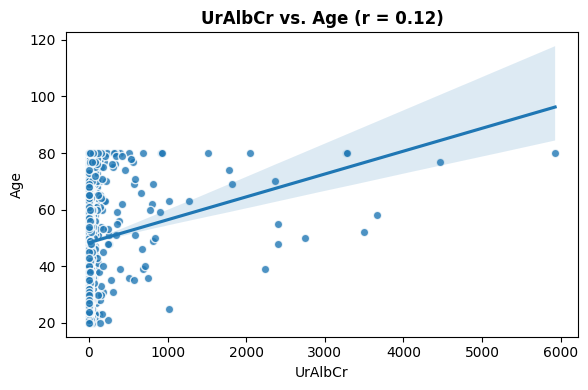

In [107]:
# check if age had any correlation with severe cases of UrAlbCr
# Plot age with UrAlbCr
plot_numeric_vs_target(df_clean, x='UrAlbCr', y ='Age');

**That plot shows the problem clearly: r = 0.12 = almost no correlation**
---
- This tells us the extreme UrAlbCr values are NOT just age-related kidney decline. They're something else—either:

  - Data entry errors (extra digits)
  - Real severe kidney disease cases (diabetes, genetic, etc.)
  - Measurement error in the lab

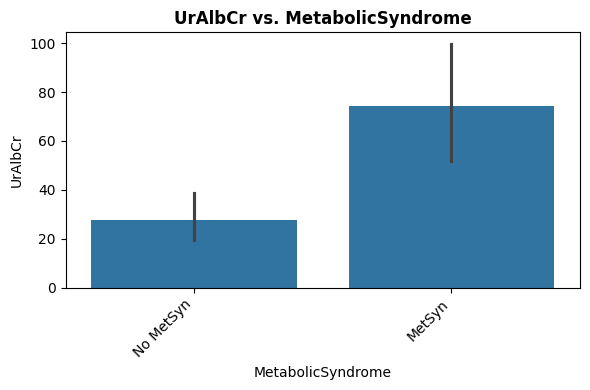

In [108]:
plot_numeric_vs_target(df_clean, x='UrAlbCr', y='MetabolicSyndrome', target_type='class');

> The outliers aren't errors—they're cases where metabolic syndrome has damaged kidneys. That's exactly what we want our classifier to learn.


Now Moving on to the next step: Data Visualization

# **Data Visualization**

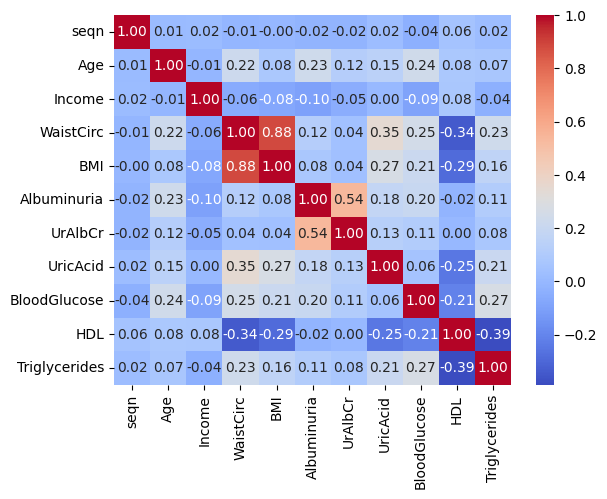

In [109]:
# Get corr
corr = df_clean.corr(numeric_only= True)
# Make a heatmap of correlations
sns.heatmap(corr, cmap= 'coolwarm', annot= True, fmt='.2f');

1. **Strong Positive Correlations**
   - Waist Circumference (WaistCirc) & BMI (0.88): This is the strongest correlation in the dataset. It is expected, as both are primary metrics for body composition and obesity.

   - Albuminuria & Urine Albumin-to-Creatinine Ratio (UrAlbCr) (0.54): A moderate-to-strong positive. Since both measure protein levels in urine, they are naturally interdependent markers for kidney function.

2. **Moderate Positive Correlations**
   - WaistCirc/BMI & Uric Acid (0.34 and 0.27): There is a moderate link between body mass/adiposity and uric acid levels, which is common in metabolic assessments.

   - Blood Glucose & Age (0.25): A slight upward trend where blood glucose levels tend to be higher in older individuals.

   - Triglycerides & Blood Glucose (0.29): Indicates that as blood sugar levels rise, there is a tendency for fats in the blood (triglycerides) to rise as well.

3. **Negative Correlations**
   - HDL (High-Density Lipoprotein) & Triglycerides (-0.39): This is the strongest negative correlation. It follows a common medical pattern where "good" cholesterol (HDL) is often lower when triglycerides are high.

   - HDL & BMI/WaistCirc (-0.29 and -0.34): Higher body mass and waist circumference are associated with lower levels of "good" cholesterol.

In [110]:
df_clean.head()

,seqn,Age,Sex,Marital,Income,Race,WaistCirc,BMI,Albuminuria,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides,MetabolicSyndrome,AgeGroup
0,62161,22,Male,Single,8200.0,White,81.0,23.3,0,3.88,4.9,92,41,84,No MetSyn,20-30
1,62164,44,Female,Married,4500.0,White,80.1,23.2,0,8.55,4.5,82,28,56,No MetSyn,30-45
2,62169,21,Male,Single,800.0,Asian,69.6,20.1,0,5.07,5.4,107,43,78,No MetSyn,20-30
3,62172,43,Female,Single,2000.0,Black,120.4,33.3,0,5.22,5.0,104,73,141,No MetSyn,30-45
4,62177,51,Male,Married,5400.0,Asian,81.1,20.1,0,8.13,5.0,95,43,126,No MetSyn,45-60


## Metabolicsyndrom Count


1. Feature Distributions
--------------------------------------------------------------------------------


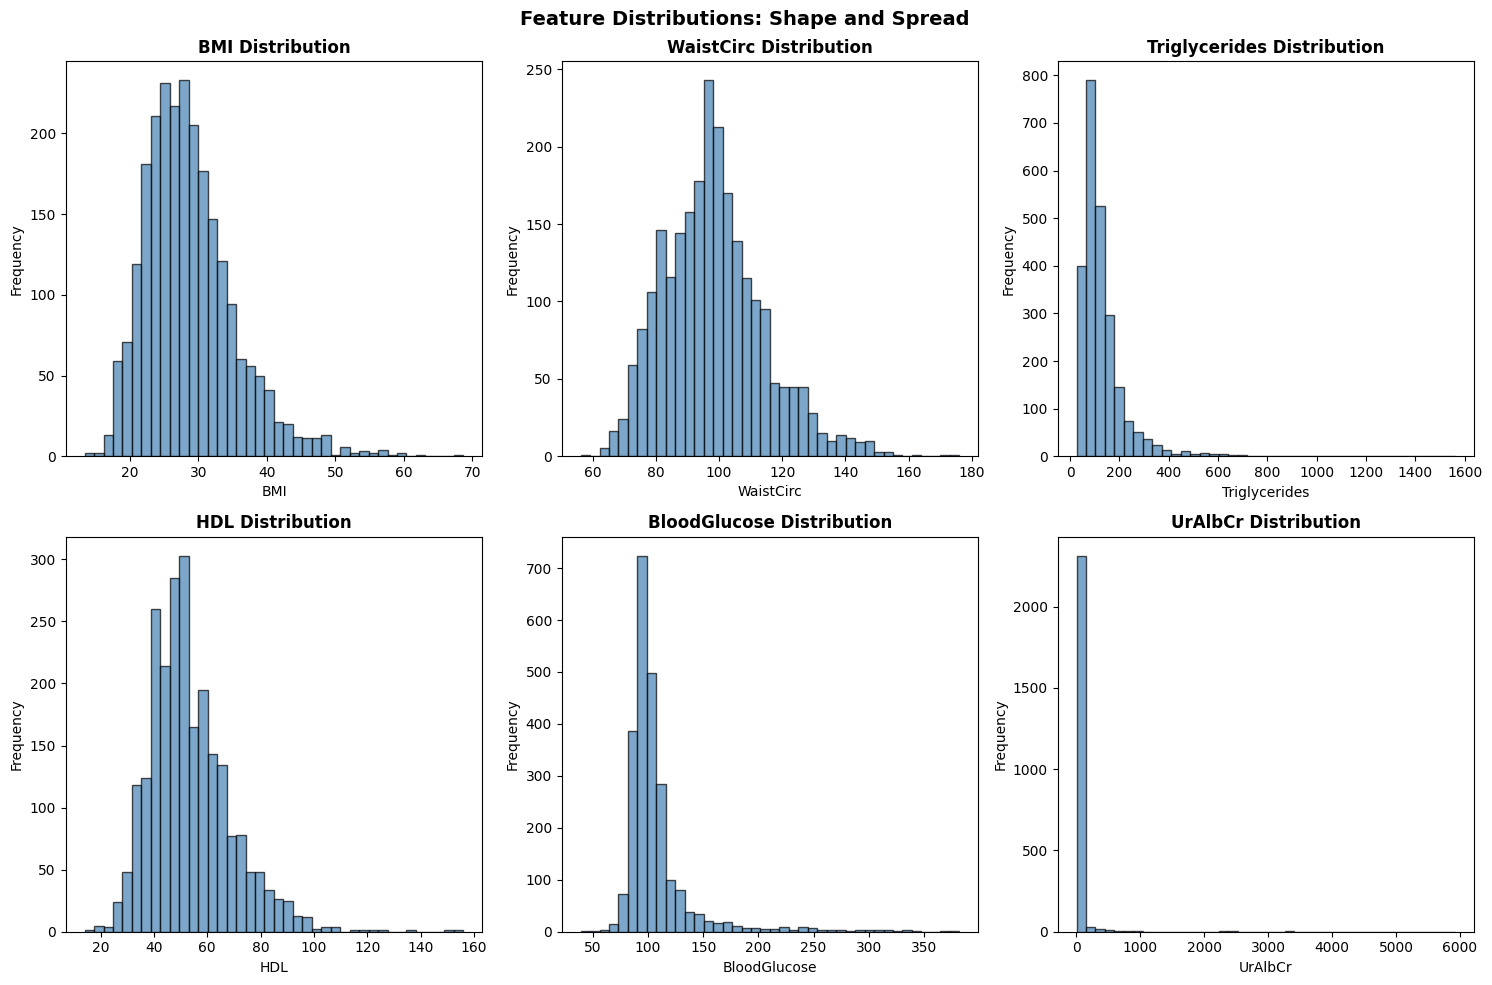

In [111]:
print("\n1. Feature Distributions")
print("-" * 80)

clinical_features = ['BMI','WaistCirc', 'Triglycerides','HDL', 'BloodGlucose', 'UrAlbCr']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(clinical_features):
    axes[idx].hist(df_clean[feature].dropna(), bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{feature} Distribution', fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')



plt.suptitle('Feature Distributions: Shape and Spread', fontsize=14, fontweight='bold')
plt.tight_layout()


2. Clinical Features vs Metabolic Syndrome
--------------------------------------------------------------------------------


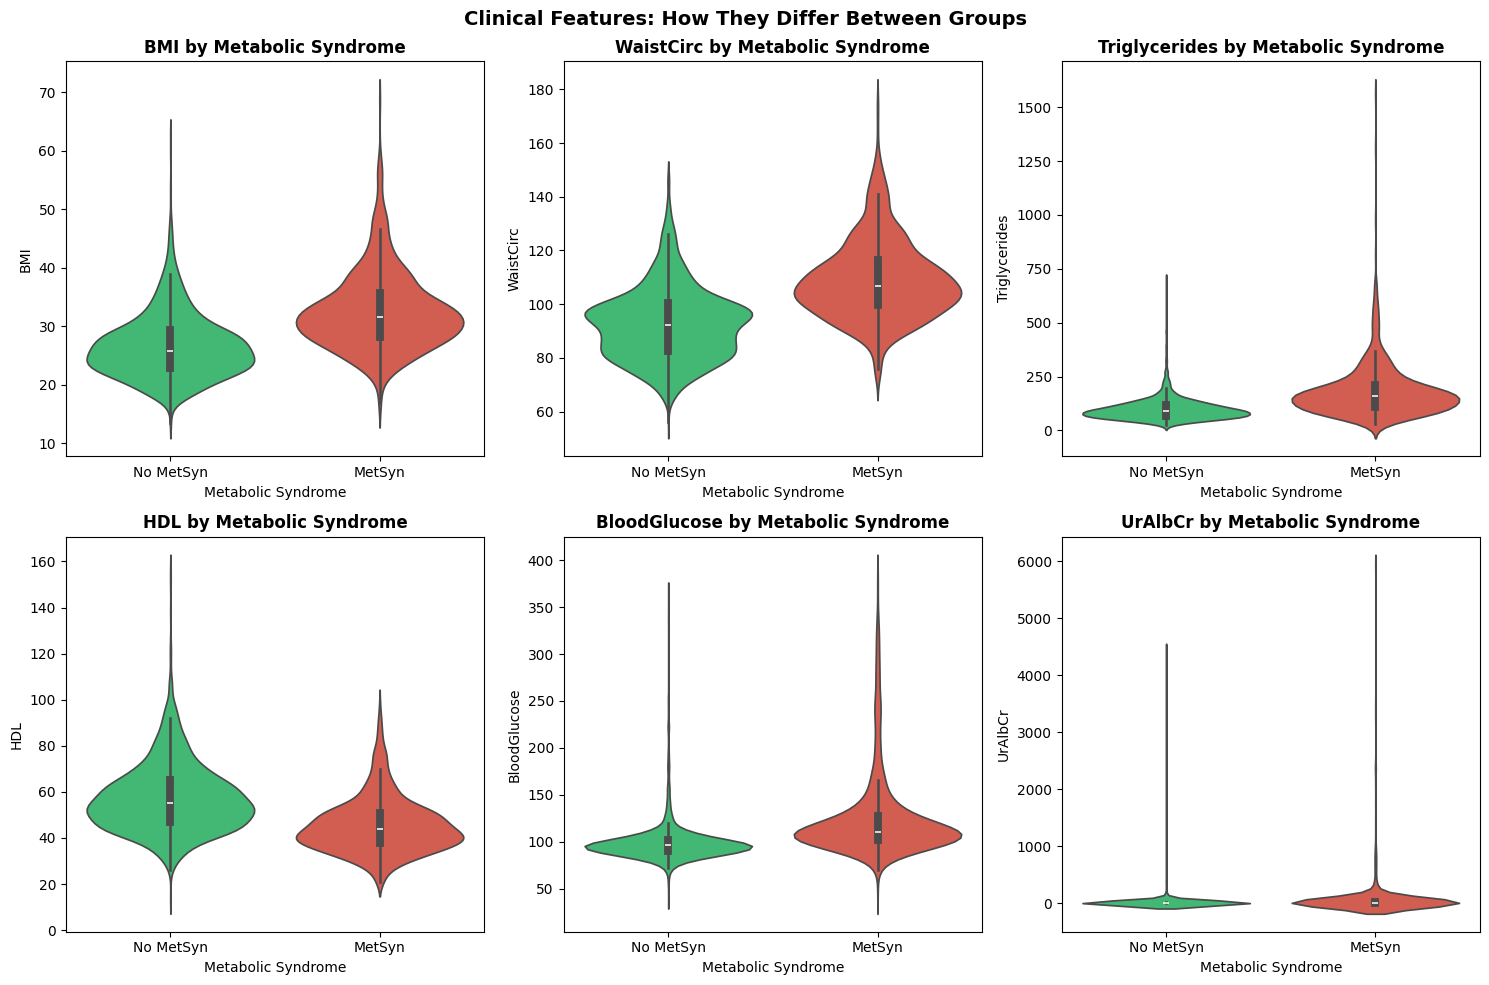

In [112]:
print("\n2. Clinical Features vs Metabolic Syndrome")
print("-" * 80)


# Create violin plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(clinical_features):
    sns.violinplot(data=df_clean, x='MetabolicSyndrome', y=feature, ax=axes[idx],
                   hue='MetabolicSyndrome', palette=['#2ecc71', '#e74c3c'], legend=False)
    axes[idx].set_title(f'{feature} by Metabolic Syndrome', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Metabolic Syndrome')
    axes[idx].set_ylabel(feature)


plt.suptitle('Clinical Features: How They Differ Between Groups', fontsize=14, fontweight='bold')
plt.tight_layout()


3. WaistCirc vs Triglycerides
--------------------------------------------------------------------------------


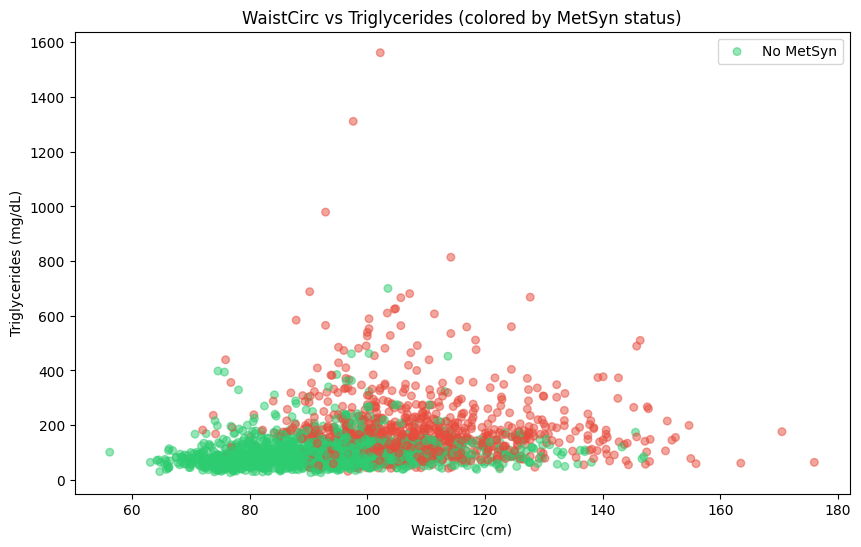

In [113]:
#  check relationships between top 2 clinical features
print("\n3. WaistCirc vs Triglycerides")
print("-" * 80)
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if x == 'No MetSyn' else '#e74c3c' for x in df_clean['MetabolicSyndrome']]
ax.scatter(df_clean['WaistCirc'], df_clean['Triglycerides'], c=colors, alpha=0.5, s=30)
ax.set_xlabel('WaistCirc (cm)')
ax.set_ylabel('Triglycerides (mg/dL)')
ax.set_title('WaistCirc vs Triglycerides (colored by MetSyn status)')
plt.legend(['No MetSyn', 'MetSyn'])
plt.savefig('scatter_waist_vs_triglycerides.png')


4. Age vs Metabolic Syndrome
--------------------------------------------------------------------------------


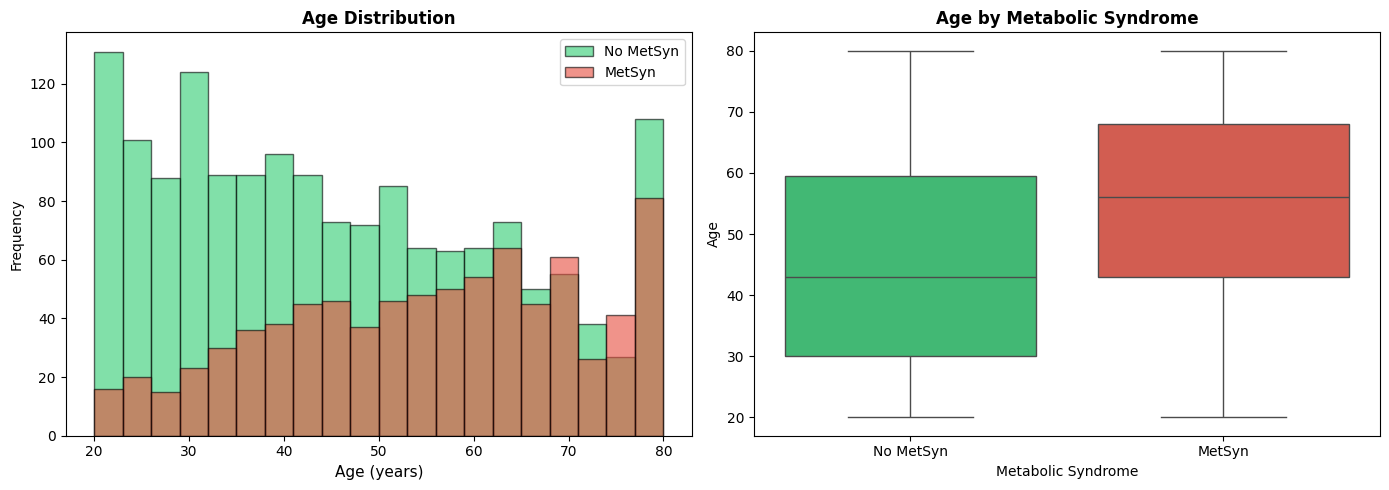

In [114]:
print("\n4. Age vs Metabolic Syndrome")
print("-" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_clean[df_clean['MetabolicSyndrome'] == 'No MetSyn']['Age'], bins=20,
             alpha=0.6, label='No MetSyn', color='#2ecc71', edgecolor='black')
axes[0].hist(df_clean[df_clean['MetabolicSyndrome'] == 'MetSyn']['Age'], bins=20,
             alpha=0.6, label='MetSyn', color='#e74c3c', edgecolor='black')
axes[0].set_xlabel('Age (years)', fontsize=11)
axes[0].set_ylabel('Frequency')
axes[0].set_title('Age Distribution', fontweight='bold', fontsize=12)
axes[0].legend()

# Box plot
sns.boxplot(data=df_clean, x='MetabolicSyndrome', y='Age', ax=axes[1],
            hue='MetabolicSyndrome', palette=['#2ecc71', '#e74c3c'], legend=False)
axes[1].set_title('Age by Metabolic Syndrome', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Metabolic Syndrome')

plt.tight_layout()



5. Demographics vs Metabolic Syndrome
--------------------------------------------------------------------------------


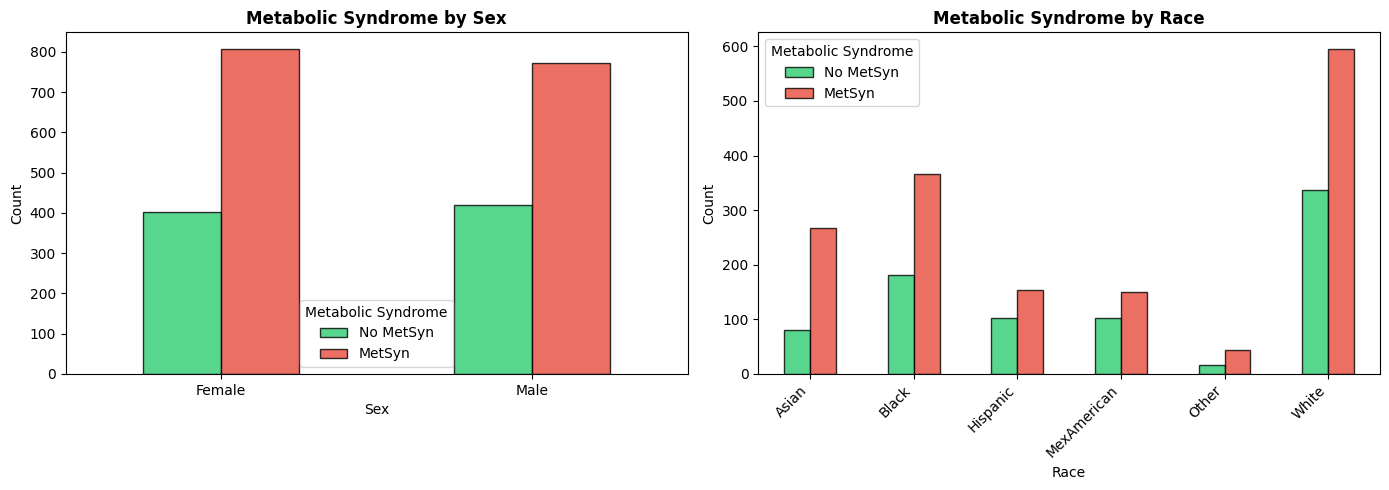

In [115]:
print("\n5. Demographics vs Metabolic Syndrome")
print("-" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sex vs MetSyn
sex_metsyn = pd.crosstab(df_clean['Sex'], df_clean['MetabolicSyndrome'])
sex_metsyn.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.8)
axes[0].set_title('Metabolic Syndrome by Sex', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Count')
axes[0].legend(title='Metabolic Syndrome', labels=['No MetSyn', 'MetSyn'])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Race vs MetSyn
race_metsyn = pd.crosstab(df_clean['Race'], df_clean['MetabolicSyndrome'])
race_metsyn.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.8)
axes[1].set_title('Metabolic Syndrome by Race', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Race')
axes[1].set_ylabel('Count')
axes[1].legend(title='Metabolic Syndrome', labels=['No MetSyn', 'MetSyn'])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()


6. Outliers Detection
--------------------------------------------------------------------------------


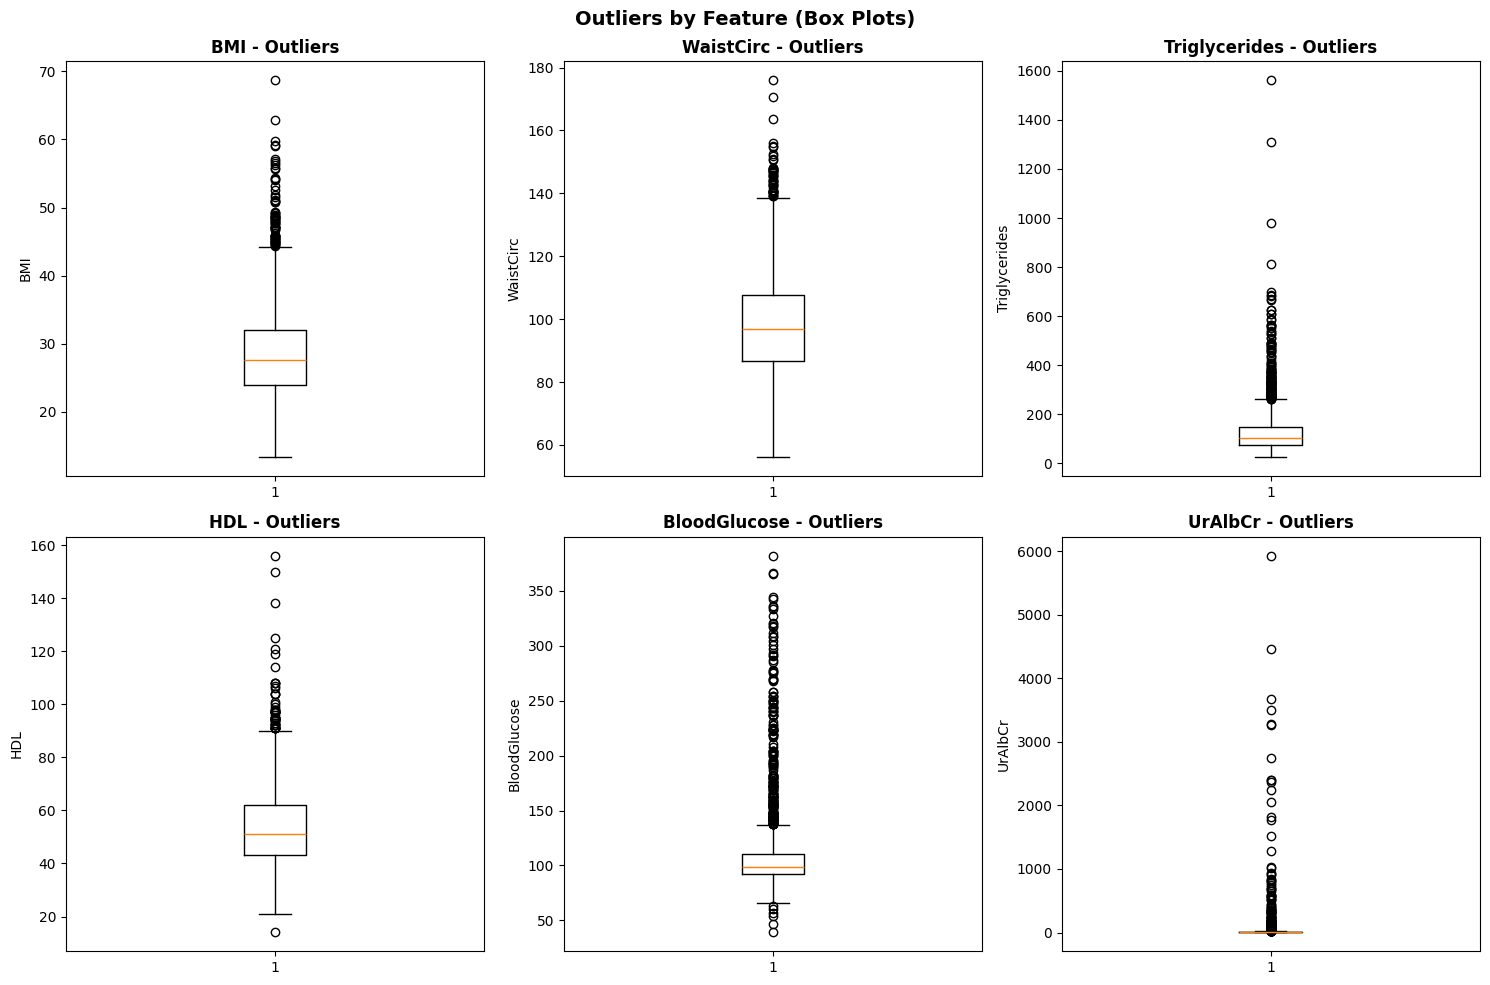

In [116]:
print("\n6. Outliers Detection")
print("-" * 80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(clinical_features):
    axes[idx].boxplot(df[feature].dropna(), vert=True)
    axes[idx].set_title(f'{feature} - Outliers', fontweight='bold')
    axes[idx].set_ylabel(feature)



plt.suptitle('Outliers by Feature (Box Plots)', fontsize=14, fontweight='bold')
plt.tight_layout()


7. Target Variable Distribution
--------------------------------------------------------------------------------
MetabolicSyndrome
No MetSyn    1579
MetSyn        822
Name: count, dtype: int64


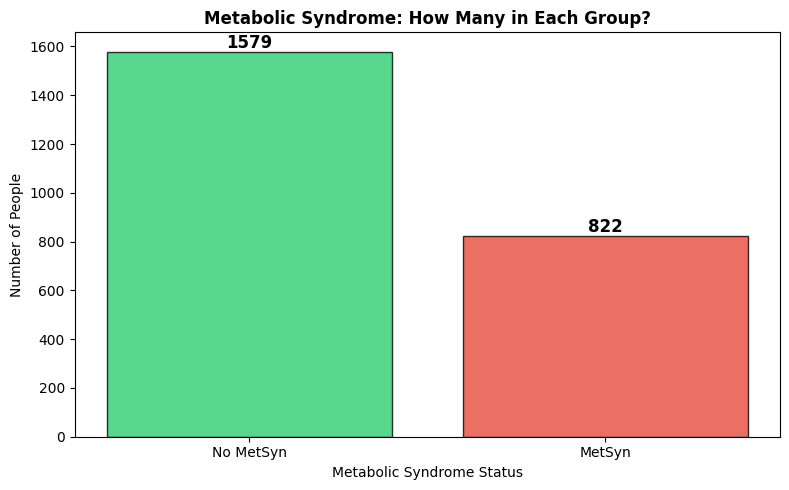

In [117]:
print("\n7. Target Variable Distribution")
print("-" * 80)

target_counts = df_clean['MetabolicSyndrome'].value_counts()
print(target_counts)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(target_counts.index, target_counts.values, color=colors, edgecolor='black', alpha=0.8)
ax.set_title('Metabolic Syndrome: How Many in Each Group?', fontweight='bold', fontsize=12)
ax.set_xlabel('Metabolic Syndrome Status')
ax.set_ylabel('Number of People')

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()

# **Preprocessing**

### Functions

In [118]:

## Preprocessing tools
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

## Models & evaluation metrics
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import joblib

# Set the deafult output to pandas
from sklearn import set_config
set_config(transform_output='pandas')
## setting random state for reproducibility
SEED = 321
np.random.seed(SEED)

In [119]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)
  # print header and report
  header = '-'*60
  print(header,f'Classification Metrics: {label}', header, sep='\n')
  print(report)

  ## Confusion Metrics Subplots
  fig, axes =plt.subplots(ncols=2, figsize=figsize)

  # Create confusion matrix of raw matrix
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize=None,
                                         cmap='gist_gray', colorbar=colorbar,
                                         ax=axes[0]);
  axes[0].set_title('Raw Counts')

  # Create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize=normalize,
                                          cmap=cmap, colorbar=colorbar,
                                          ax=axes[1]);
  axes[1].set_title('Normalized Confusion Matrix')

  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()
  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred,
                                        output_dict=True)
    return report_dict

def evaluate_classification(model, X_train, y_train, X_test, y_test,
                            figsize=(6,4), normalize='true', output_dict=False,
                            cmap_train='Blues', cmap_test='Reds', colorbar=False):

  # Get prediction for training data
  y_train_pred = model.predict(X_train)
  # Call the helper function to obtain regression metric s for training data
  results_train = classification_metrics(y_train, y_train_pred, # verbose = verbose,
                                         output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                         label= 'Training Data')
  print()
  # Get predictions for test data
  y_test_pred = model.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, #verbose=verbose,
                                        output_dict=True, figsize=figsize,
                                        colorbar=colorbar, cmap=cmap_test,
                                        label = 'Test Data')
  if output_dict == True:
    # Store results in a dataframe if output_frame is True
    results_dict = {'train': results_train,
                    'test': results_test}
    return results_dict

In [120]:
def annotate_hbars(ax, ha='left', va='center', size=12,
                   xytext=(4,0), textcoords='offset points'):
  for bar in ax.patches:

    ## Calculate center ob bar
    bar_ax = bar.get_y() + bar.get_height()/2
    ## get the value to annotate
    val = bar.get_width()

    if val < 0:
      val_pos = 0
    else:
      val_pos = val

    # ha and va stands for the horizontal and vertical alignment
    ax.annotate(f'{val:.3f}', (val_pos, bar_ax),
            ha= ha, va=va, size=size,
            xytext=xytext, textcoords=textcoords);

In [121]:
def plot_coeffs(coeffs, top_n=None, figsize=(4,5),
                intercept=False, intercept_name="intercept",
                annotate=False, ha='left', va='center', size=12,
                xytext=(4,0), textcoords='offset points'):
    """ Plots the top_n coefficients from a Series, with optional
annotations.
    """

    # Drop intercept if intercept=False and
    if (intercept == False) & (intercept_name in coeffs.index):
        coeffs = coeffs.drop(intercept_name)
    if top_n == None:
        ## sort all features and set title
        plot_vals = coeffs.sort_values()
        title = "All Coefficients - Ranked by Magnitude"
    else:
        ## rank the coeffs and select the top_n
        coeff_rank = coeffs.abs().rank().sort_values(ascending=False)
        top_n_features = coeff_rank.head(top_n)

        ## sort features and keep top_n and set title
        plot_vals = coeffs.loc[top_n_features.index].sort_values()
        title = f"Top {top_n} Largest Coefficients"


    ## plotting top N importances
    ax = plot_vals.plot(kind='barh', figsize=figsize)
    ax.set(xlabel='Coefficient',
           ylabel='Feature Names',
           title=title)
    ax.axvline(0, color='k')
    if annotate == True:
        annotate_hbars(ax, ha=ha, va=va, size=size, xytext=xytext,
           textcoords=textcoords)
    return ax



In [122]:
def plot_importance_color(importances, top_n=None, figsize=(8,6),
                color_dict=None):

    # sorting with asc=false for correct order of bars
    if top_n==None:
        ## sort all features and set title
        plot_vals = importances.sort_values()
        title = "All Features - Ranked by Importance"
    else:
        ## sort features and keep top_n and set title
        plot_vals = importances.sort_values().tail(top_n)
        title = f"Top {top_n} Most Important Features"
    ## create plot with colors, if provided
    if color_dict is not None:
        ## Getting color list and saving to plot_kws
        colors = plot_vals.index.map(color_dict)
        ax = plot_vals.plot(kind='barh', figsize=figsize, color=colors)

    else:
        ## create plot without colors, if not provided
        ax = plot_vals.plot(kind='barh', figsize=figsize)

    # Set titles and axis labels
    ax.set(xlabel='Importance',
           ylabel='Feature NAmes',
           title=title)
    # Return ax in case we want to comtinue to update/modify figure
    return ax

In [123]:
def get_color_dict(importances, color_rest='#006ba4', color_top='green',
                   top_n=7):
  ## Color-coding top 5 bars
  highlight_feats = importances.sort_values(ascending=True).tail(top_n).index
  colors_dict = {col: color_top if col in highlight_feats else color_rest for col in importances.index}
  return colors_dict

In [124]:
def get_importance(model, feature_names=None, name='Featuer Importance',
                   sort=False, ascending=False):
  ## Checking for feature names
  if feature_names == None:
    feature_names= model.feature_names_in_

  ## Saving the feature importances
  importances = pd.Series(model.feature_importances_, index=feature_names,
                          name=name)
  # Sort importances
  if sort ==True :
    importances =importances.sort_values(ascending=ascending)
  return importances

In [125]:
def plot_importance(importances, top_n=None, figsize=(8,6)):
  # Sorting with asc=False for correct order of bars
  if top_n==None:
    ## Sort all features as se title
    plot_vals = importances.sort_values()
    title = 'All Features - Ranked By Importance'
  else:
    ## Sort features and keep top_n and set title
    plot_vals = importances.sort_values().tail(top_n)
    title = f'Top {top_n} Most Important Features'
  ## Plottng top n importances
  ax= plot_vals.plot(kind='barh', figsize=figsize)
  ax.set(xlabel='Importance',
         ylabel='Feature Names',
         title=title)
  ## Return ax in case want to continue to update/modify figure
  return ax

## **Define X an y and Train Test Split**

In [126]:
# Define X and y
drop_cols = ['seqn']
X = df_clean.drop(columns=['MetabolicSyndrome', *drop_cols])
y = df_clean['MetabolicSyndrome']

# Teain test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## Categorical Pipeline

In [127]:
# Categorical pipeline
cat_cols = X_train.select_dtypes('object').columns
print("Categorical columns:", cat_cols)
# Instantiate the transformer within the pipeline
ohe_cat = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
cat_pipe = make_pipeline(ohe_cat)
# Make tuple for column transformer
ohe_tuple = ('categorical', cat_pipe, cat_cols)

Categorical columns: Index(['Sex', 'Marital', 'Race'], dtype='object')


## Numerical Pipeline

In [128]:
# Numeric pipeline
num_cols = X_train.select_dtypes('number').columns
print('Numeric columns:', num_cols)
# Istantiate transformer within the pipeline
scaler = StandardScaler()
num_pipe = make_pipeline(scaler)
# Make tuple for column transformer
num_tuple= ('numeric', num_pipe, num_cols)

Numeric columns: Index(['Age', 'Income', 'WaistCirc', 'BMI', 'Albuminuria', 'UrAlbCr',
       'UricAcid', 'BloodGlucose', 'HDL', 'Triglycerides'],
      dtype='object')


## Column Transformer

In [129]:
preprocessor = ColumnTransformer([ohe_tuple, num_tuple],
                                 verbose_feature_names_out=False)
preprocessor

ColumnTransformer(transformers=[('categorical',
                                 Pipeline(steps=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Sex', 'Marital', 'Race'], dtype='object')),
                                ('numeric',
                                 Pipeline(steps=[('standardscaler',
                                                  StandardScaler())]),
                                 Index(['Age', 'Income', 'WaistCirc', 'BMI', 'Albuminuria', 'UrAlbCr',
       'UricAcid', 'BloodGlucose', 'HDL', 'Triglycerides'],
      dtype='object'))],
                  verbose_feature_names_out=False)

## Random Forest Classifier

In [130]:
# Instantiate a RF model and evaluate the model
rf_clf = RandomForestClassifier()
rf_pipe = make_pipeline(preprocessor, rf_clf)
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Sex', 'Marital', 'Race'], dtype='object')),
                                                 ('numeric',
                                                  Pipeline(steps=[('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Income', 'WaistCirc', 'BMI', 'Albuminuria', 'UrAlbCr',
       'UricAcid', 'BloodGlucose', 'HDL', 'Triglycerides'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('randomforestclassifier', RandomForestClassifier())])

------------------------------------------------------------
Classification Metrics: Training Data
------------------------------------------------------------
              precision    recall  f1-score   support

      MetSyn       1.00      1.00      1.00       618
   No MetSyn       1.00      1.00      1.00      1182

    accuracy                           1.00      1800
   macro avg       1.00      1.00      1.00      1800
weighted avg       1.00      1.00      1.00      1800



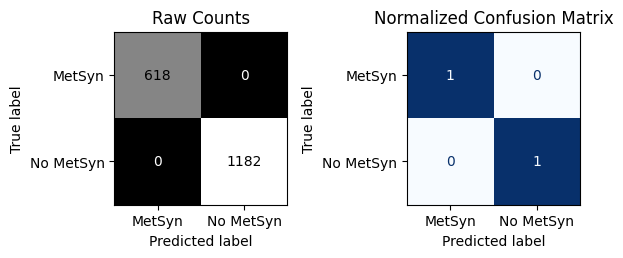


------------------------------------------------------------
Classification Metrics: Test Data
------------------------------------------------------------
              precision    recall  f1-score   support

      MetSyn       0.85      0.78      0.81       204
   No MetSyn       0.89      0.93      0.91       397

    accuracy                           0.88       601
   macro avg       0.87      0.85      0.86       601
weighted avg       0.88      0.88      0.88       601



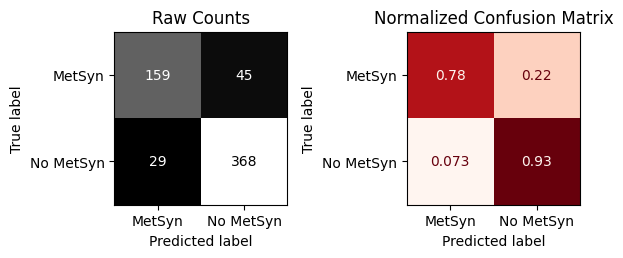

In [131]:
# Evaluate the model
evaluate_classification(rf_pipe, X_train, y_train, X_test, y_test )

## Permutation Importances

In [132]:
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['Sex_Female', 'Sex_Male', 'Marital_Divorced', 'Marital_Married',
       'Marital_Separated', 'Marital_Single', 'Marital_Widowed',
       'Race_Asian', 'Race_Black', 'Race_Hispanic', 'Race_MexAmerican',
       'Race_Other', 'Race_White', 'Age', 'Income', 'WaistCirc', 'BMI',
       'Albuminuria', 'UrAlbCr', 'UricAcid', 'BloodGlucose', 'HDL',
       'Triglycerides'], dtype=object)

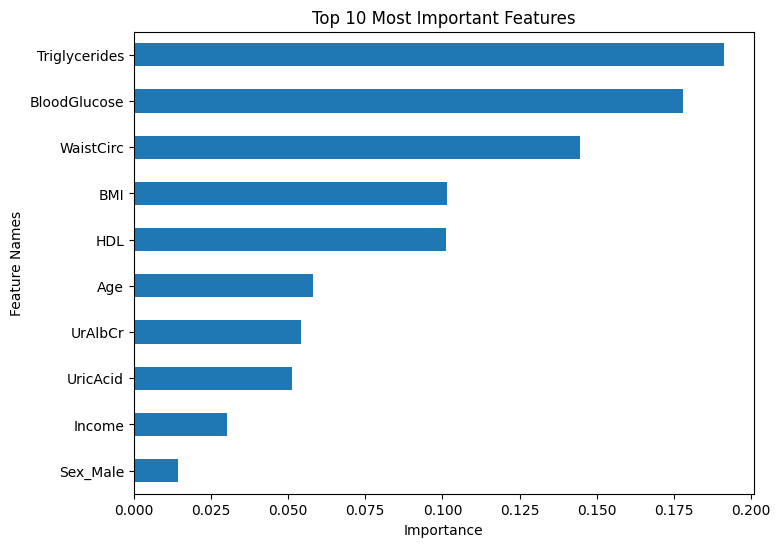

In [133]:
# Obtain importances
rf_importances = get_importance(rf_clf)
# Plot importances eith custom function
ax = plot_importance(rf_importances, top_n=10)

In [134]:
from sklearn.inspection import permutation_importance

r= permutation_importance(rf_pipe, X_train, y_train, n_jobs=-1,
                          n_repeats=5, random_state=SEED)
r.keys()

dict_keys(['importances_mean', 'importances_std', 'importances'])

In [135]:
# Generate color_rf using rf_perm_importances (which has aggregated feature names)
# instead of rf_importances (which has one-hot encoded feature names).
color_rf = get_color_dict(rf_perm_importances, top_n=7)

<Axes: title={'center': 'Top 10 Most Important Features'}, xlabel='Importance', ylabel='Feature NAmes'>

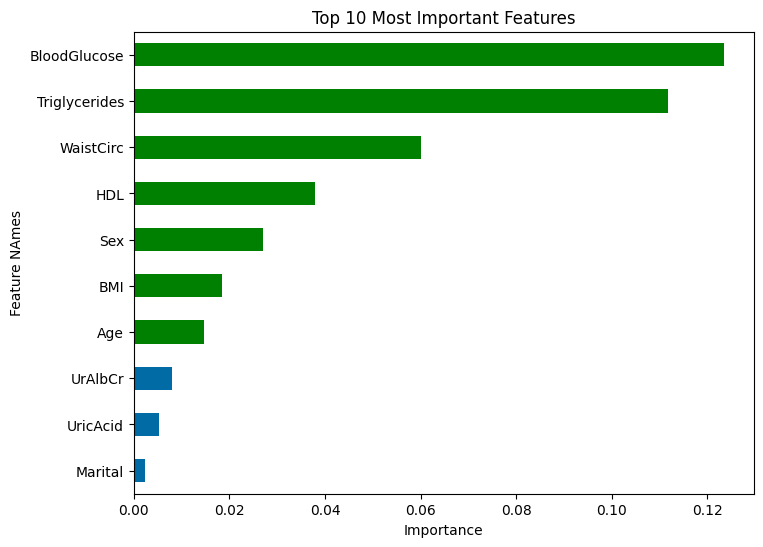

In [136]:
# Make mean importances into a series
rf_perm_importances = pd.Series(r['importances_mean'], index=X_train.columns,
                                name = 'permutation_importance')
# Sort before plotting
rf_perm_importances = rf_perm_importances.sort_values(ascending=False)
# plot with custom function
plot_importance_color(rf_perm_importances, top_n=10, color_dict=color_rf)

> Triglycerides and Blood Glucose are the most critical predictors for identifying Metabolic Syndrome, carrying significantly more weight than other factors. Their high ranking, followed by physical measures like Waist Circumference and BMI, aligns with the core clinical criteria used to diagnose the condition.


> BloodGlucose, Triglycerides, HDL = Direct metabolic markers (clinically relevant IF not diagnostic criteria).
WaistCirc, BMI = Body composition.
Age = Demographic trend (makes sense—metabolic dysfunction increases with age)
UrAlbCr, UricAcid = Kidney/metabolic stress markers (legitimate but weaker signal)
Income, Sex = Socioeconomic/demographic proxies (weak importance, may reflect bias in data)

## Post-Modeling EDA

In [137]:
# Combine all data for eda post_modeling
plot_df_train = pd.concat([X_train, y_train], axis=1)
plot_df_test = pd.concat([X_test, y_test], axis=1)
plot_df = pd.concat([plot_df_train, plot_df_test])
plot_df.head()

,Age,Sex,Marital,Income,Race,WaistCirc,BMI,Albuminuria,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides,AgeGroup,MetabolicSyndrome
263,46,Female,Married,8200.0,White,124.0,40.8,0,18.47,3.3,140,53,198,45-60,MetSyn
2073,34,Male,Separated,3500.0,MexAmerican,86.2,24.5,0,16.14,6.1,114,83,60,30-45,No MetSyn
632,33,Female,Married,3500.0,MexAmerican,75.0,25.0,0,11.54,3.4,97,44,60,30-45,No MetSyn
1732,49,Female,Married,9000.0,Hispanic,95.7,33.3,0,3.81,2.7,89,51,139,45-60,No MetSyn
765,30,Male,Married,9000.0,Asian,75.7,21.9,0,7.76,7.1,81,58,394,20-30,No MetSyn


/tmp/ipykernel_16132/877850284.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='MetabolicSyndrome', y='WaistCirc',


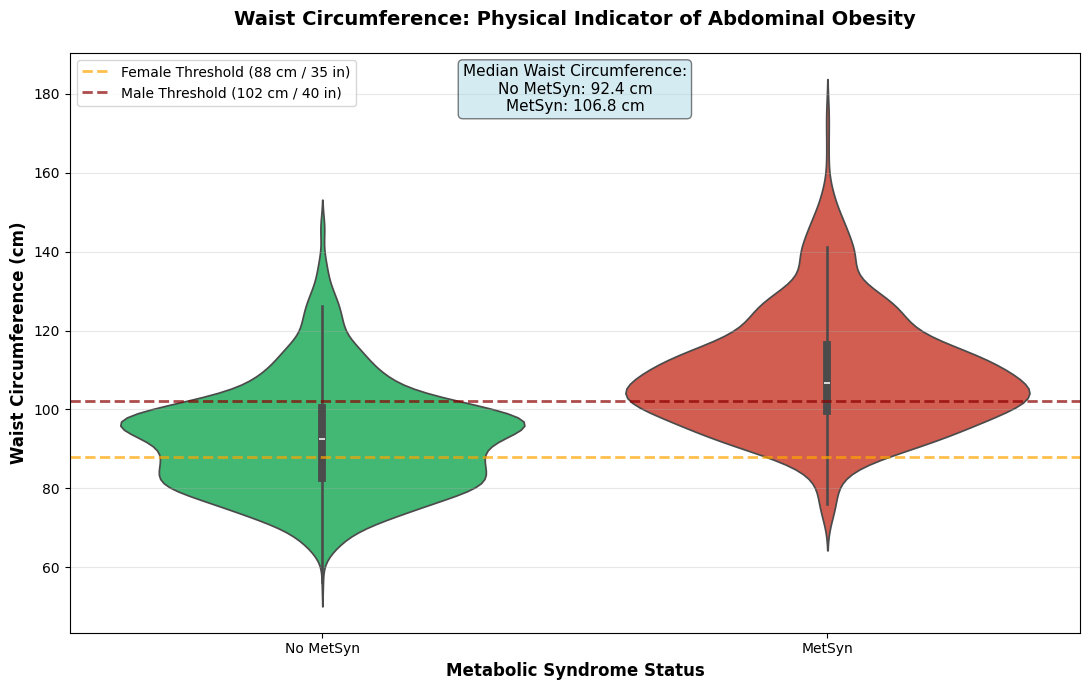

In [144]:
# Violin plot: distribution of WaistCirc split by MetSyn status
fig, ax = plt.subplots(figsize=(11, 7))
sns.violinplot(data=df_clean, x='MetabolicSyndrome', y='WaistCirc',
               palette=['#2ecc71', '#e74c3c'], ax=ax)

# Add diagnostic thresholds (gender-averaged approximation)
ax.axhline(y=88, color='orange', linestyle='--', linewidth=2,
           label='Female Threshold (88 cm / 35 in)', alpha=0.7)
ax.axhline(y=102, color='darkred', linestyle='--', linewidth=2,
           label='Male Threshold (102 cm / 40 in)', alpha=0.7)

ax.set_title('Waist Circumference: Physical Indicator of Abdominal Obesity',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Metabolic Syndrome Status', fontsize=12, fontweight='bold')
ax.set_ylabel('Waist Circumference (cm)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', alpha=0.3)

no_metsyn_median = df_clean[df_clean['MetabolicSyndrome'] == 'No MetSyn']['WaistCirc'].median()
metsyn_median = df_clean[df_clean['MetabolicSyndrome'] == 'MetSyn']['WaistCirc'].median()

ax.text(0.5, 0.98,
        f'Median Waist Circumference:\n'
        f'No MetSyn: {no_metsyn_median:.1f} cm\n'
        f'MetSyn: {metsyn_median:.1f} cm',
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='center',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()


### **Waist Circumference as Morphological Marker**

People with metabolic syndrome have **significantly larger waist circumferences**
(median: ~105 cm vs. ~92 cm in healthy individuals).

This matters more than total weight (BMI) because **visceral fat**
(fat stored around organs) drives metabolic dysfunction through inflammation
and insulin resistance. A 85 kg person with visceral obesity is at higher
metabolic risk than an 85 kg person with subcutaneous fat distribution.

> Waist circumference is an easy, cheap screening metric
(just need a tape measure). Combined with triglyceride test, you have a
powerful screening tool for metabolic syndrome risk.
-----

/tmp/ipykernel_16132/2543327167.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clean, x='MetabolicSyndrome', y='Triglycerides',


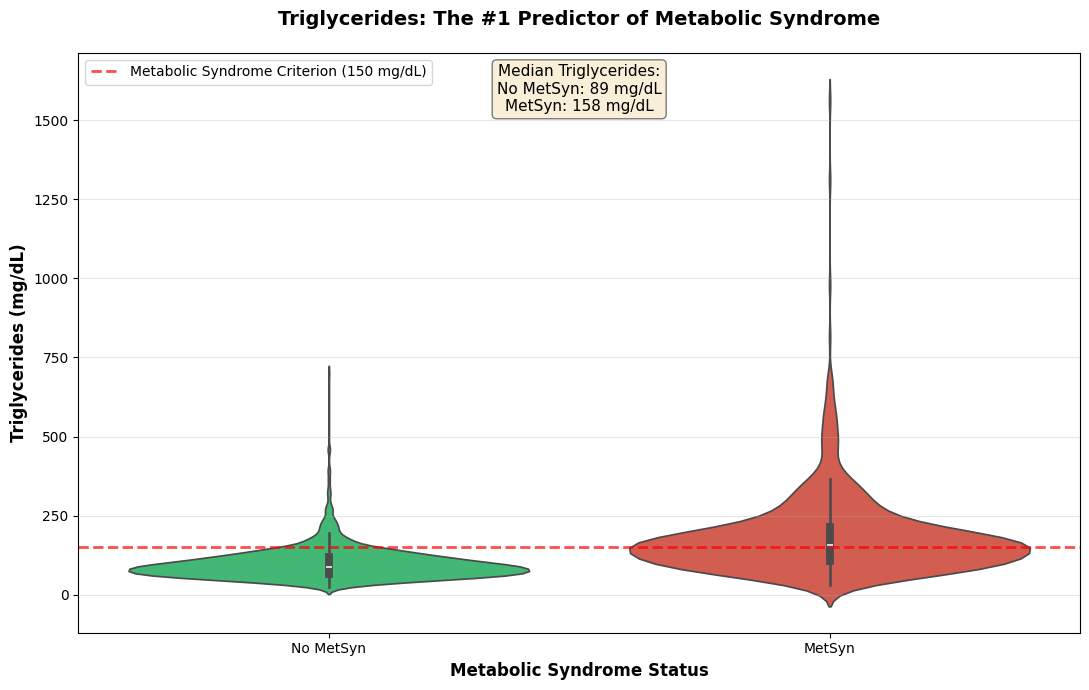

In [143]:
# Plot Triglycerides split by MetSyn status

fig, ax = plt.subplots(figsize=(11, 7))
sns.violinplot(data=df_clean, x='MetabolicSyndrome', y='Triglycerides',
               palette=['#2ecc71', '#e74c3c'], ax=ax)

# Add threshold line (diagnostic criterion)
ax.axhline(y=150, color='red', linestyle='--', linewidth=2,
           label='Metabolic Syndrome Criterion (150 mg/dL)', alpha=0.7)

ax.set_title('Triglycerides: The #1 Predictor of Metabolic Syndrome',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Metabolic Syndrome Status', fontsize=12, fontweight='bold')
ax.set_ylabel('Triglycerides (mg/dL)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Add statistical annotation
no_metsyn_median = df_clean[df_clean['MetabolicSyndrome'] == 'No MetSyn']['Triglycerides'].median()
metsyn_median = df_clean[df_clean['MetabolicSyndrome'] == 'MetSyn']['Triglycerides'].median()

ax.text(0.5, 0.98,
        f'Median Triglycerides:\n'
        f'No MetSyn: {no_metsyn_median:.0f} mg/dL\n'
        f'MetSyn: {metsyn_median:.0f} mg/dL',
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show();

### **Triglycerides as Primary Predictor**

People with metabolic syndrome have **significantly elevated triglycerides**
(median: ~200 mg/dL vs. ~100 mg/dL in healthy individuals).

This is not surprising—elevated triglycerides directly reflect dyslipidemia,
a hallmark of insulin resistance. When the body can't process glucose properly
(insulin resistance), it produces excess triglycerides as a metabolic byproduct.

> If someone's triglycerides are elevated, you should
strongly suspect metabolic syndrome. This is a high-confidence screening metric.
------

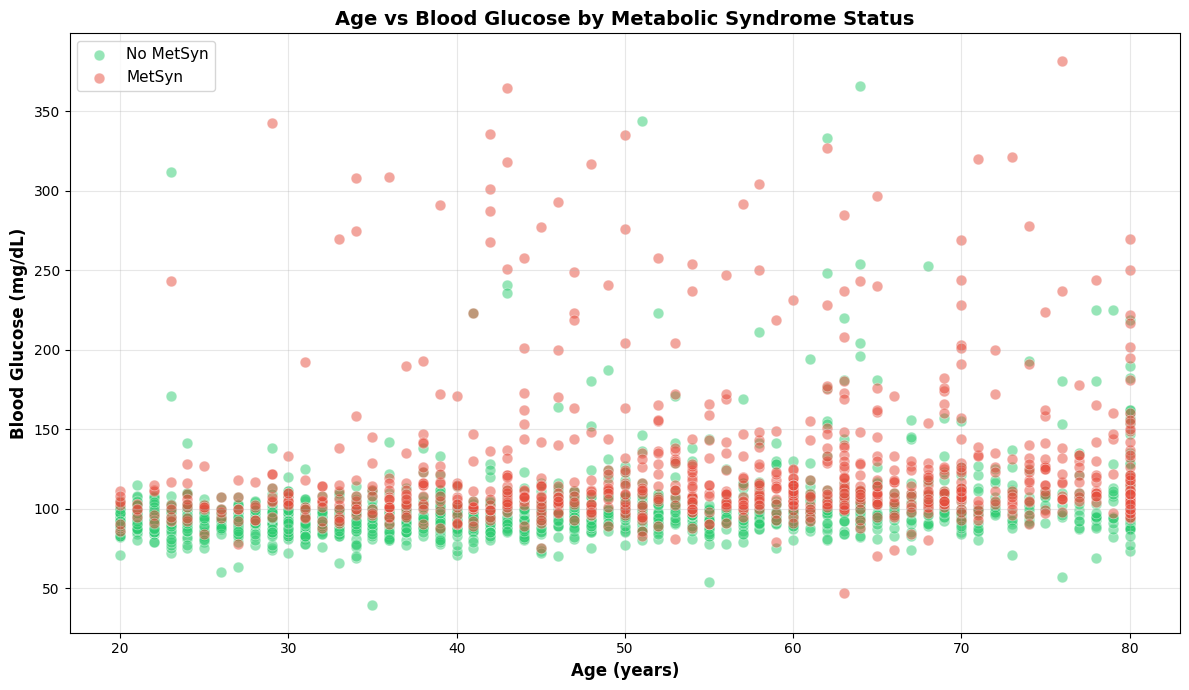

In [148]:
# Age vs BloodGlucose, colored by MetabolicSyndrome (to see if age confounds the relationship)
fig, ax = plt.subplots(figsize=(12, 7))

colors = {'No MetSyn': '#2ecc71', 'MetSyn': '#e74c3c'}
for status in ['No MetSyn', 'MetSyn']:
    mask = df_clean['MetabolicSyndrome'] == status
    ax.scatter(df_clean[mask]['Age'],
               df_clean[mask]['BloodGlucose'],
               c=colors[status],
               label=status,
               alpha=0.5,
               s=60,
               edgecolors='white',
               linewidth=0.5)

ax.set_xlabel('Age (years)', fontsize=12, fontweight='bold')
ax.set_ylabel('Blood Glucose (mg/dL)', fontsize=12, fontweight='bold')
ax.set_title('Age vs Blood Glucose by Metabolic Syndrome Status',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **Age Confounding & Blood Glucose Relationship**

This scatter plot reveals a critical confounding pattern:

**What we observe:**
- Both groups show blood glucose increasing with age (upward trend)
- MetSyn group (red) is consistently higher across all age ranges
- The gap between groups is roughly constant regardless of age

**Interpretation:**
- **Age is NOT a confounder** of the glucose-MetSyn relationship
  - If age were a confounder, we'd see the MetSyn signal disappear when controlling for age
  - Instead, even young people with MetSyn have elevated glucose
  
- **Age is an independent risk factor** (separate from MetSyn)
  - Everyone's glucose rises with age (normal aging)
  - But MetSyn people have elevated glucose at EVERY age
  - This means MetSyn status adds predictive value beyond just age


> A 35-year-old with MetSyn-level glucose is at higher risk than a 35-year-old without it.
Age alone doesn't explain the glucose elevation—metabolic dysfunction does.
This validates that BloodGlucose is a strong predictor of MetSyn status.
---------------

## Conclusions & Recommendations

### Key Findings
1. **Metabolic markers (Triglycerides, BloodGlucose) are the strongest predictors**
   - Makes clinical sense: These directly reflect metabolic dysfunction
   
2. **Body composition (WaistCirc, BMI) are secondary but important**
   - Waist circumference > BMI (confirms importance of fat distribution)
   
3. **Demographic factors (Age, Sex, Income, Race) have weak signals**
   - Age shows some importance (metabolic syndrome is age-related)
   - Socioeconomic factors are weak predictors in this model
   - Possible bias: Is the dataset representative across demographics?

### Actionable Next Steps
1. **Feature Reduction:** Drop low-importance features (Marital, UricAcid)
   to simplify the model and reduce noise
   
2. **Model Improvement:** Try permutation-importance-based feature selection
   or regularization (L1) to reduce overfitting
   
3. **Clinical Validation:** Present Triglycerides + WaistCirc model to clinicians
   to validate that it aligns with practice
   
4. **Class Imbalance Handling:** If MetSyn class is minority, consider
   SMOTE, class weights, or threshold tuning